# Complete R&D workflow: pack variability, uncertainty, sensitivity, and decisions

Built with [Vicena](https://vicena.ai). This notebook extends the reference twin with a synthetic 12s2p pack, group-aware uncertainty, stress sensitivity, and a Pareto screen. Pack outputs and optimization values remain Level 0 because the pack parameters are illustrative. Calendar-aging prediction intervals use measured Level 1 data.

In [1]:
from pathlib import Path
import sys,json
sys.path.insert(0,str(Path('..')/'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from battery_twin import *
out=Path('../outputs'); out.mkdir(exist_ok=True)

In [2]:
t=np.arange(0,1801,2.0); current=np.where(t<600,8,np.where(t<900,0,5))
pack,cells=simulate_pack(t,current,pack=PackParameters(series_cells=12,parallel_cells=2))
print('Pack topology: 12 series x 2 parallel, illustrative variability')
print(f'Minimum cell voltage: {pack.cell_voltage_min_v.min():.4f} V')
print(f'Maximum cell temperature: {pack.cell_temperature_max_c.max():.3f} C')
print(f'Maximum SOC spread: {pack.soc_spread.max():.4f}')
pack.to_csv(out/'pack_profile.csv',index=False)

Pack topology: 12 series x 2 parallel, illustrative variability
Minimum cell voltage: 3.4456 V
Maximum cell temperature: 26.555 C
Maximum SOC spread: 0.0637


In [3]:
df=load_calendar_ageing('../datasets/measured/calendar_ageing')
base_model,base_metrics,_,_,_=fit_evaluate(df)
_,conf,intervals=conformal_evaluate(base_model,df)
boot=grouped_bootstrap_metrics(base_model,df,n_boot=200)
print('Conformal metrics:',json.dumps(conf,indent=2))
print('Grouped bootstrap:',json.dumps(boot,indent=2))
intervals.to_csv(out/'conformal_intervals.csv',index=False)

Conformal metrics: {
  "alpha": 0.1,
  "interval_half_width": 0.0621001983813152,
  "empirical_coverage": 0.9586776859504132,
  "test_rows": 121,
  "test_groups": 27
}
Grouped bootstrap: {
  "mae_point": 0.02846238817205229,
  "mae_ci95_low": 0.022954301807154454,
  "mae_ci95_high": 0.03450482781607316,
  "bootstrap_replicates": 200
}


In [4]:
s=stress_sensitivity(); policies=pareto_policies()
print('Stress cases:',len(s))
print('Pareto policies:',int(policies.pareto.sum()))
print(policies.loc[policies.pareto,['temperature_c','storage_soc','efc_per_day','throughput_efc','soh']].to_string(index=False))
s.to_csv(out/'stress_sensitivity.csv',index=False); policies.to_csv(out/'pareto_policies.csv',index=False)

Stress cases: 36
Pareto policies: 3
 temperature_c  storage_soc  efc_per_day  throughput_efc      soh
            15          0.3          0.2            73.0 0.991970
            15          0.3          0.7           255.5 0.990845
            15          0.3          1.2           438.0 0.989946


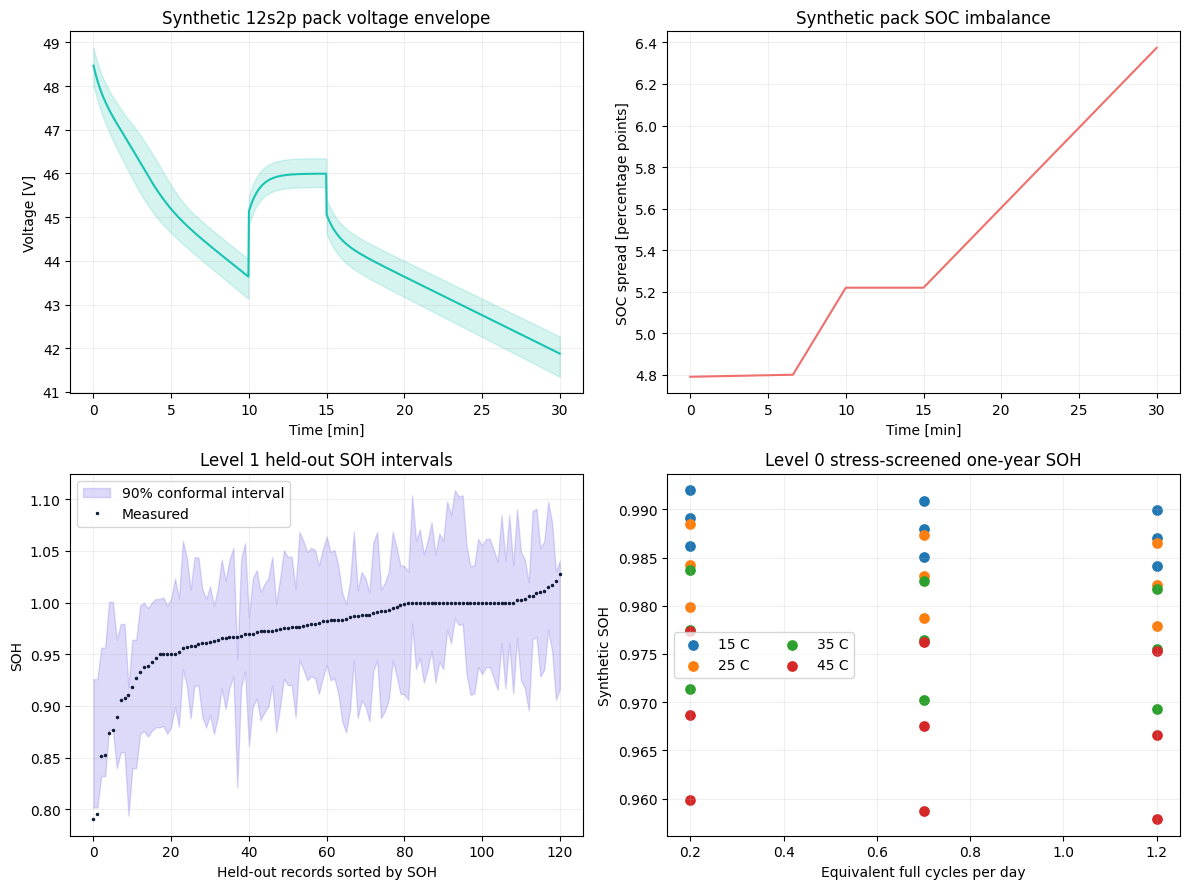

In [5]:
fig,ax=plt.subplots(2,2,figsize=(12,9))
ax[0,0].plot(pack.time_s/60,pack.pack_voltage_v,color='#19c3b1'); ax[0,0].fill_between(pack.time_s/60,pack.cell_voltage_min_v*12,pack.cell_voltage_max_v*12,color='#19c3b1',alpha=.18); ax[0,0].set(title='Synthetic 12s2p pack voltage envelope',xlabel='Time [min]',ylabel='Voltage [V]')
ax[0,1].plot(pack.time_s/60,pack.soc_spread*100,color='#ef6f6c'); ax[0,1].set(title='Synthetic pack SOC imbalance',xlabel='Time [min]',ylabel='SOC spread [percentage points]')
o=intervals.sort_values('soh').reset_index(drop=True); x=np.arange(len(o)); ax[1,0].fill_between(x,o.lower_soh,o.upper_soh,color='#7868e6',alpha=.25,label='90% conformal interval'); ax[1,0].plot(x,o.soh,'.',ms=3,color='#101b35',label='Measured'); ax[1,0].set(title='Level 1 held-out SOH intervals',xlabel='Held-out records sorted by SOH',ylabel='SOH'); ax[1,0].legend()
for temp,g in s.groupby('temperature_c'): ax[1,1].scatter(g.efc_per_day,g.soh,s=45,label=f'{temp} C')
ax[1,1].set(title='Level 0 stress-screened one-year SOH',xlabel='Equivalent full cycles per day',ylabel='Synthetic SOH'); ax[1,1].legend(ncol=2)
for a in ax.flat:a.grid(alpha=.2)
fig.tight_layout(); fig.savefig(out/'complete_rd_workflow.png',dpi=180); plt.show()

## Decision boundary

The Pareto screen ranks synthetic operating policies by throughput and retained SOH. It is useful for experimental design and trade-space exploration, not for warranty, safety, or fleet decisions. Replace the synthetic aging law with independently validated cell-specific evidence before operational use.